### import packages

In [1]:
import os, re
from langchain_ollama import ChatOllama
import psutil, subprocess
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, RemoveMessage

### define graph bulder

In [ ]:

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

#### Langsmith Keys

In [ ]:
LANGCHAIN_API_KEY = ""
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "chatbot_v1"

### Summarize conversation

In [4]:
def format_convo(msg):
    convo = ""
    for vl in msg:
        convo = convo + f"{vl.type}:: {vl.content} \n"
    return convo

In [ ]:
def llm_call(msg : State):
    if len(msg["messages"]) > 1:
        print("within with summary")
        summary = format_convo(msg["messages"][:-1])
        user_input = "Conversation So far::\n" + summary + "\n" + "Latest User Question::\n" + msg["messages"][-1].content
        print("completed within with summary")  
    else:
        print("within without summary")
        user_input = msg["messages"][-1].content

    llm_chat = ChatOllama(model="qwen2:latest")
    llm_rslt = llm_chat.invoke([HumanMessage(content=user_input)])
    print(llm_rslt)
    return {"messages": llm_rslt}

### Build and compile Graph

In [7]:
builder = StateGraph(State)
builder.add_node('llm_call', llm_call)

builder.add_edge(START, 'llm_call')
builder.add_edge('llm_call', END)
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

### Display Graph

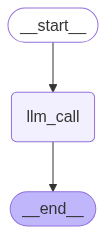

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Ollama Utilities

In [ ]:
def stop_ollama(name_pattern = '.*ollama.*'):
    # Regex pattern to match process names
    pattern = re.compile(name_pattern, re.IGNORECASE)

    for proc in psutil.process_iter(['pid', 'name']):
        try:
            # Check if process name matches the pattern
            if pattern.search(proc.info['name']):
                proc.terminate()
                proc.wait(timeout=5)
                print(f"Successfully stopped process with PID: {proc.info['pid']} and Name: {proc.info['name']}")
        except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.TimeoutExpired) as e:
            print(f"Failed to stop process {proc.info['name']} with PID {proc.info['pid']}. Error: {e}")

stop_ollama()

In [12]:
def start_ollama_server():
    # Check if Ollama is already running
    for proc in psutil.process_iter(['name']):
        if proc.info['name'] == 'ollama':
            print("Ollama server is already running")
            return
    
    try:
        subprocess.Popen(["ollama", "serve"])
        print("Ollama server started in background")
    except subprocess.CalledProcessError:
        print("Failed to start Ollama server")

start_ollama_server()        

Ollama server started in background


### Initiate the chat

In [13]:
config = {"configurable": {"thread_id": "1"}}

while True:
    user_input = input("Enter your question")
    if user_input == "q":
        break
    else:
        llm_rslt = graph.invoke({"messages": [HumanMessage(content = user_input)]}, config)
        print("graph prints")
        print(llm_rslt)

within without summary
content="As an AI, I don't exist physically and therefore I'm not located anywhere in the traditional sense. However, I'm currently running on servers operated by Alibaba Cloud. If you have any questions or need assistance with something, feel free to ask!" additional_kwargs={} response_metadata={'model': 'qwen2:latest', 'created_at': '2025-05-23T17:15:31.2412427Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2843133100, 'load_duration': 1805291700, 'prompt_eval_count': 22, 'prompt_eval_duration': 62421900, 'eval_count': 51, 'eval_duration': 973670800, 'model_name': 'qwen2:latest'} id='run-04f95b19-3516-4b57-a62a-1f995a4a4320-0' usage_metadata={'input_tokens': 22, 'output_tokens': 51, 'total_tokens': 73}
graph prints
{'messages': [HumanMessage(content='Where are you', additional_kwargs={}, response_metadata={}, id='ca96985d-8f2c-4966-aa8f-dda07f7d9d32'), AIMessage(content="As an AI, I don't exist physically and therefore I'm not located anywhere in the